In [21]:
import numpy as np

data = np.load('rom1.npy', allow_pickle=True).item()
print("Available branches:", list(data['pressure'].keys()))

for branch in data['pressure']:
    raw = data['pressure'][branch]
    arr = np.array(raw)
    print(f"branch={branch}", "type:", type(raw), "shape:", arr.shape, "ndim:", arr.ndim, "size:", arr.size)
    if arr.ndim == 0:
        print("  scalar value:", arr.item())
    elif arr.ndim == 1:
        print("  first/last:", arr[0], arr[-1])
    else:
        print("  1st row first/last:", arr[0, 0], arr[0, -1], "last row first/last:", arr[-1, 0], arr[-1, -1])

Available branches: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
branch=0 type: <class 'dict'> shape: () ndim: 0 size: 1
  scalar value: {0: array([[124723.493802, 124723.493802, 124723.493802, 124723.493802,
        124723.493802],
       [124721.574762, 124721.574762, 124721.574762, 124721.574762,
        124721.574762],
       [124719.619244, 124719.619244, 124719.619244, 124719.619244,
        124719.619244],
       [124717.626372, 124717.626372, 124717.626372, 124717.626372,
        124717.626372],
       [124715.611578, 124715.611578, 124715.611578, 124715.611578,
        124715.611578],
       [124697.126785, 124697.126785, 124697.126785, 124697.126785,
        124697.126785]])}
branch=1 type: <class 'dict'> shape: () ndim: 0 size: 1
  scalar value: {0: array([[124697.126785, 124697.126785, 124697.126785, 124697.126785,
        124697.126785],
       [119961.951733, 119961.951733, 119961.951733, 119961.951733,
        119961.951733],
       [119147.962906, 119147.9

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def pressure_array_from_branch(raw):
    # option A: dict-of-options (time-steps or sub-branches)
    if isinstance(raw, dict):
        # choose last (or explicit) key scenario
        keys = sorted(raw.keys())
        if len(keys) == 0:
            raise ValueError("empty pressure dict")
        raw = raw[keys[-1]]

    arr = np.asarray(raw, dtype=np.float64)
    if arr.ndim == 0:
        arr = arr.reshape(-1)
    return arr

# load once
data = np.load('rom1.npy', allow_pickle=True).item()
branches = sorted(data['pressure'].keys())   # or your order

for target_branch in branches:
    raw_data = data['pressure'][target_branch]
    branch_pressure = pressure_array_from_branch(raw_data)

    # if branch_pressure is 2D, last time snapshot:
    plot_data = branch_pressure[-1] if branch_pressure.ndim > 1 else branch_pressure

    if plot_data.size < 2:
        raise ValueError("not enough nodes to compute FFR for branch", target_branch)

    p_in = float(plot_data[0])
    p_out = float(plot_data[-1])
    ffr = p_out / p_in

    # plotting logic as before
    num_nodes = plot_data.shape[0] if plot_data.ndim == 1 else plot_data.shape[1]
    ...

In [27]:
for branch in sorted(data['pressure']):
    raw = data['pressure'][branch]
    print(branch, type(raw),
          "-> keys" if isinstance(raw, dict) else "", 
          getattr(raw, "keys", lambda: None)(), 
          "-> shaped", np.asarray(raw).shape)

0 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
1 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
2 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
3 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
4 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
5 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
6 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
7 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
8 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
9 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
10 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
11 <class 'dict'> -> keys dict_keys([0]) -> shaped ()
12 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
13 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
14 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
15 <class 'dict'> -> keys dict_keys([0, 1, 2]) -> shaped ()
16 <class 'dict'> -> keys dict_keys([0]) -> shaped ()


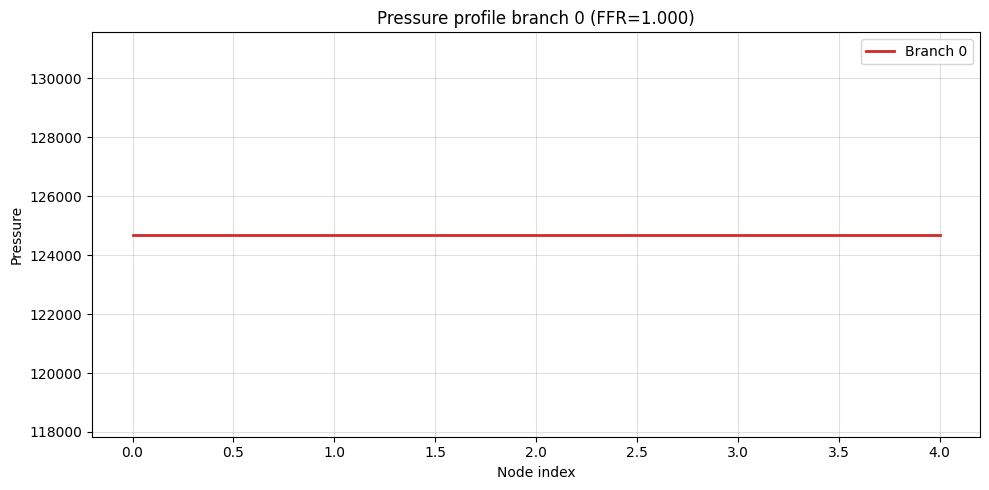

Branch 0: p_in=124697.127, p_out=124697.127, FFR=1.000


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def get_pressure_array(raw):
    # raw is dict like {0: ndarray, 1: ndarray, ...}; choose last time point
    if isinstance(raw, dict):
        keys = sorted(raw.keys())
        if not keys:
            raise ValueError("empty branch pressure dict")
        raw = raw[keys[-1]]
    arr = np.asarray(raw, dtype=np.float64)
    if arr.ndim == 0:
        arr = arr.reshape(-1)
    return arr

data = np.load("rom1.npy", allow_pickle=True).item()
branches = sorted(data["pressure"].keys())

# choose branch index or iterate all
target_branch = branches[0]
raw_branch = data["pressure"][target_branch]
branch_press = get_pressure_array(raw_branch)

# if 2D: use last time step; if 1D: use directly
plot_data = branch_press[-1] if branch_press.ndim > 1 else branch_press

if plot_data.size < 2:
    raise ValueError(f"not enough nodes in branch {target_branch} for profile")

p_in = float(plot_data[0])
p_out = float(plot_data[-1])
ffr = p_out / p_in

if plot_data.ndim == 1:
    nodes = np.arange(plot_data.shape[0])
else:
    nodes = np.arange(plot_data.shape[1])

plt.figure(figsize=(10, 5))
plt.plot(nodes, plot_data, color="#d62728", linewidth=2, label=f"Branch {target_branch}")
plt.title(f"Pressure profile branch {target_branch} (FFR={ffr:.3f})")
plt.xlabel("Node index")
plt.ylabel("Pressure")
plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Branch {target_branch}: p_in={p_in:.3f}, p_out={p_out:.3f}, FFR={ffr:.3f}")